In [168]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [169]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [170]:
df['Gender'] = df['Gender'].map({'Female':0,'Male':1})

In [171]:
model = KMeans(n_clusters=3,random_state=42)
model.fit(df) #learns the pattern

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [172]:
model.predict(df) #predicts the cluster values

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [173]:
df['result'] = model.fit_predict(df)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),result
0,1,1,19,15,39,2
1,2,1,21,15,81,2
2,3,0,20,16,6,2
3,4,0,23,16,77,2
4,5,0,31,17,40,2


In [174]:
cluster_0 = df[df['result']==0]
cluster_1 = df[df['result']==1]
cluster_2 = df[df['result']==2]


## Elbow method
It is used for selecting the best cluster value,
inertia_-> Kmeans metric

In [175]:
scores=[]
for i in range(2,11):
    model = KMeans(n_clusters=i,random_state=42)
    model.fit(df)
    #inertia_
    scores.append(model.inertia_)
print(scores)

[387181.5881588159, 271396.5629660315, 195415.20399892007, 157535.54099944432, 122799.7728927935, 113352.8704874336, 86247.28275791317, 82292.62576312576, 75313.01535766551]


<Axes: >

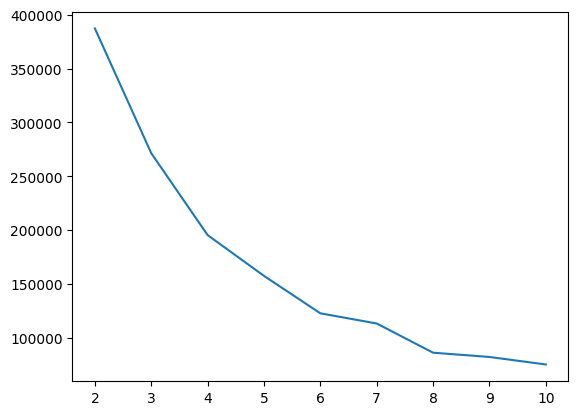

In [176]:
# plt.scatter(range(2,11),scores,linewidths=0.3)
sns.lineplot(x =range(2,11),y=scores,markers='o')

4 is the best cluster for this mall customer scenario.

In [177]:
from sklearn.decomposition import PCA

In [178]:
pca_ = PCA(n_components=2)
updated_df = pca_.fit_transform(df) #df => 5

In [179]:
updated_df[:,1]

array([-5.47821548e+00,  3.49319738e+01, -3.78406049e+01,  3.05629117e+01,
       -7.29652043e+00,  2.98014646e+01, -4.13225212e+01,  4.70715237e+01,
       -5.09235461e+01,  2.40348349e+01, -4.09176881e+01,  4.91525724e+01,
       -3.78936561e+01,  3.02510553e+01, -3.50271590e+01,  3.26454846e+01,
       -1.31738617e+01,  2.04352621e+01, -2.29454573e+01,  4.81074838e+01,
       -1.32187336e+01,  2.60554010e+01, -4.49588139e+01,  2.46590405e+01,
       -3.80712074e+01,  3.38439646e+01, -1.84961057e+01,  1.20179415e+01,
       -1.83386257e+01,  4.00613921e+01, -4.92290792e+01,  2.68779606e+01,
       -4.76543768e+01,  4.60234987e+01, -3.70123982e+01,  3.46199673e+01,
       -3.25026190e+01,  2.47487400e+01, -2.23987678e+01,  2.89590557e+01,
       -2.03200785e+01,  4.45655035e+01, -1.54606066e+01,  1.27711414e+01,
       -2.34850477e+01,  1.82618545e+01,  2.54389188e+00,  3.69284693e-02,
       -5.29370221e+00, -5.75828821e+00, -1.81942999e-01,  1.12731071e+01,
        5.88167668e+00,  

In [180]:
model = KMeans(n_clusters=4,random_state=42)
clusters= model.fit_predict(df)

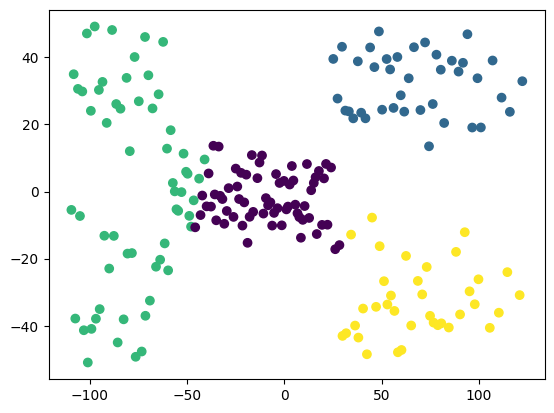

In [181]:
plt.scatter(updated_df[:,0],updated_df[:,1],c=clusters)

In [182]:
clusters

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

<Axes: >

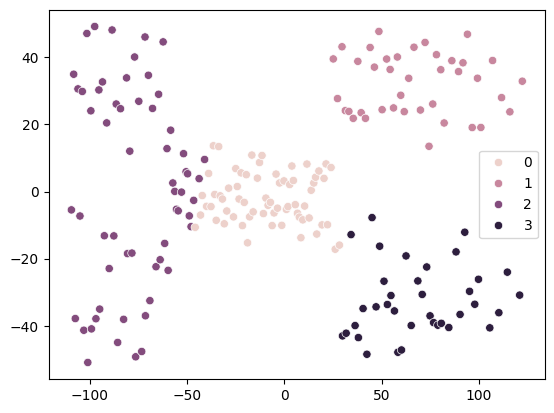

In [183]:
sns.scatterplot(x=updated_df[:,0],y=updated_df[:,1],hue=clusters)

In [ ]:
from sklearn.decomposition import PCA
pca_ = PCA(n_components=3) #0.9,0.95,0.98
updated_df = pca_.fit_transform(df)
pca_.explained_variance_ratio_ #0.95
# 0.8188633 + 0.14166735
''' 
How it works ?
PC1=>0.8188633
PC2=>0.14166735
n_components=0.95
PC1 is not reached 0.95 so it adds PC2 to check the explained ratio 0.95
Yes,After adding PC1+PC2 variance ratio we got 0.95% variance ratio,

So finally from 5 correlated features into 2 new features created
'''

array([[-1.09388107e+02, -5.47821548e+00, -2.23718157e+01],
       [-1.08207030e+02,  3.49319738e+01, -1.07824392e+01],
       [-1.07380489e+02, -3.78406049e+01, -2.89722099e+01],
       [-1.06012007e+02,  3.05629117e+01, -9.74580048e+00],
       [-1.04984516e+02, -7.29652043e+00, -1.04470465e+01],
       [-1.03778959e+02,  2.98014646e+01, -1.09364335e+01],
       [-1.03000694e+02, -4.13225212e+01, -1.43575966e+01],
       [-1.01431011e+02,  4.70715237e+01, -5.81535010e+00],
       [-1.00956341e+02, -5.09235461e+01,  1.31753009e+01],
       [-9.93847986e+01,  2.40348349e+01, -4.05008867e+00],
       [-9.90748236e+01, -4.09176881e+01,  1.86056524e+01],
       [-9.74083723e+01,  4.91525724e+01,  7.00256780e+00],
       [-9.67820128e+01, -3.78936561e+01,  1.00913697e+01],
       [-9.52566712e+01,  3.02510553e+01, -8.74116437e+00],
       [-9.48460304e+01, -3.50271590e+01, -1.08095711e+01],
       [-9.34053808e+01,  3.26454846e+01, -1.02411744e+01],
       [-9.24542919e+01, -1.31738617e+01

In [185]:
pca_.explained_variance_ratio_ #0.95
# 0.8188633 + 0.14166735

array([0.8188633 , 0.14166735, 0.0341283 ])